In [1]:
import os
import re
import sys
import pandas as pd
import numpy as np
import tensorflow as tf

from IPython.display import display
import matplotlib.pyplot as plt

sys.path.append('custom_modules')
from PipeDataCsvWorker import PipeDataCsvWorker

from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Reshape, Input, Dense, Flatten, Conv2D, Dropout, Conv2DTranspose
from tensorflow.keras.layers import MaxPooling2D, UpSampling2D, concatenate, BatchNormalization

2023-12-20 10:58:11.064572: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-20 10:58:11.137824: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-20 10:58:11.137878: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-20 10:58:11.137916: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-20 10:58:11.151287: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-20 10:58:13.305355: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
# paths for files with original data
RUN_1_PATH = ('data/Original data/Run1/run1_WM32_data.csv',
        'data/Original data/Run1/run1_WM32_defects.csv',
        'data/Original data/Run1/run1_WM32_pipe.csv')
 
RUN_2_PATH = ('data/Original data/Run2/run2_WM32_data.csv',
        'data/Original data/Run2/run2_WM32_defects.csv',
        'data/Original data/Run2/run2_WM32_pipe.csv')

CROP_SIZE = 64
CROP_STEP = 20

# детерминация случайных величин, отвечающих за выбор первоначальных весов и биасов
tf.compat.v1.set_random_seed(290)
tf.random.set_seed(290)

# чтение данных
test_1 = PipeDataCsvWorker(*RUN_1_PATH)

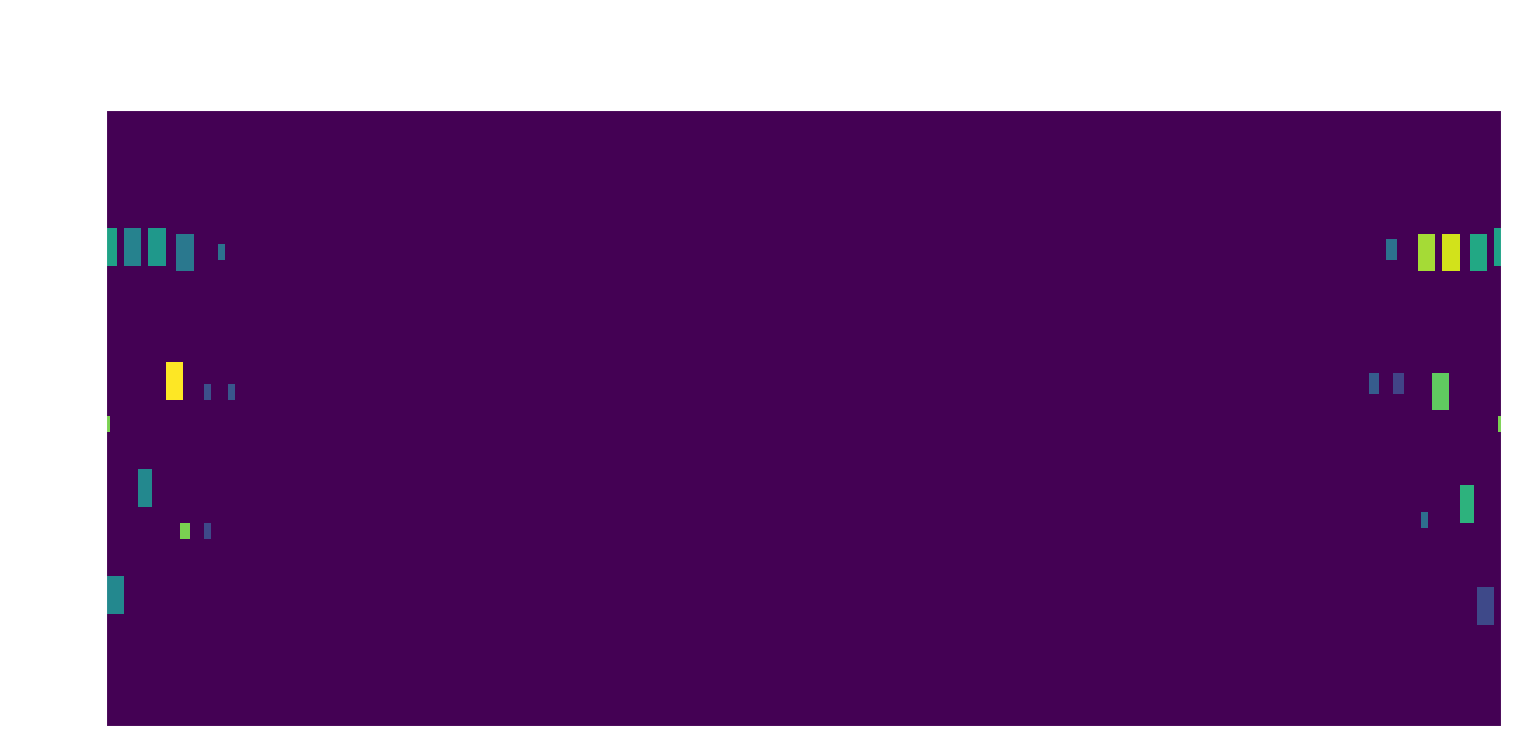

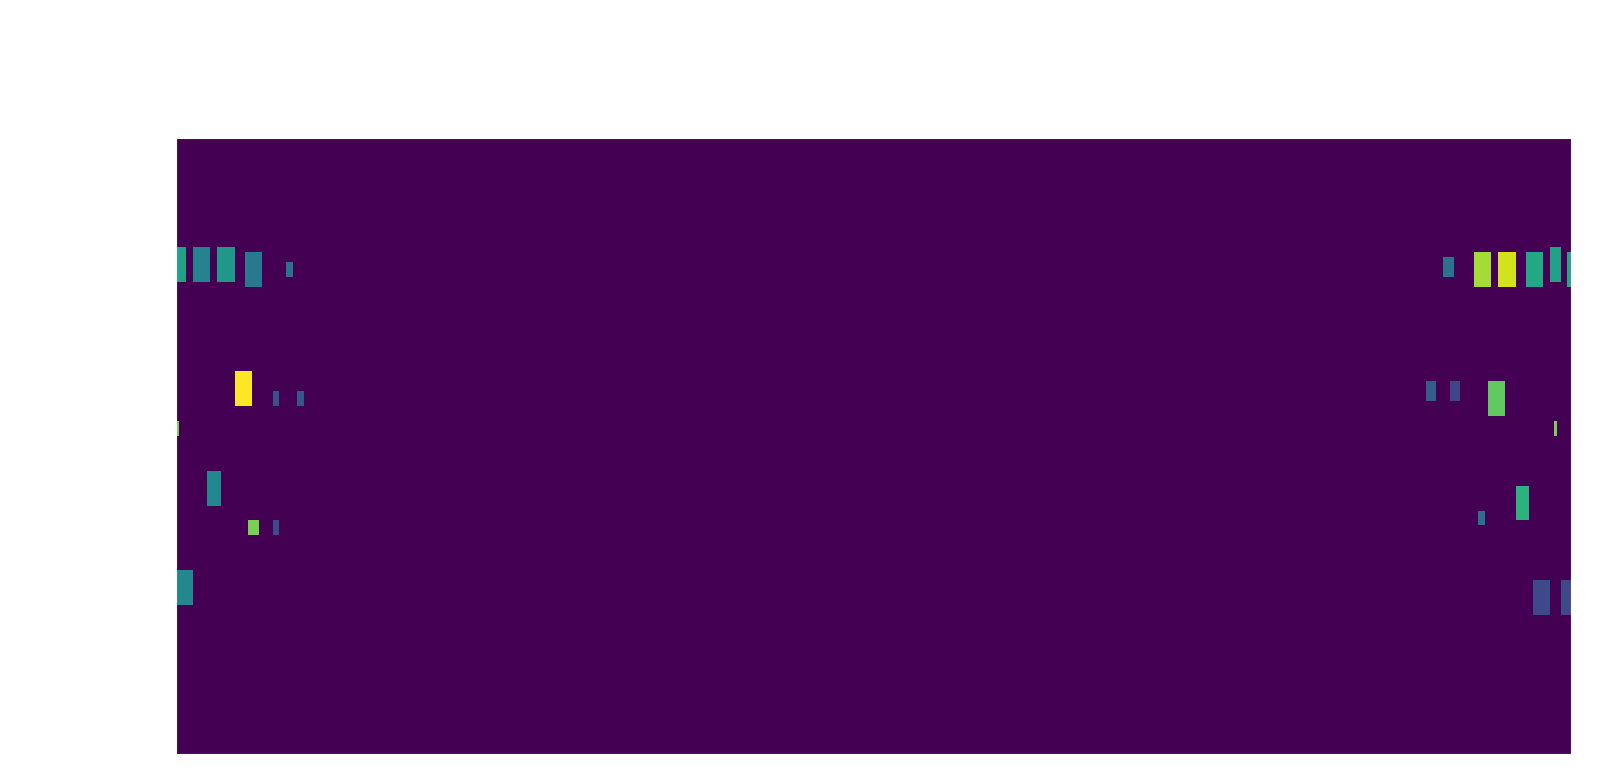

In [3]:
# Вывод считанных данных и их расширение для обучения
test_1.draw_defects_map(title='Считанная развернутая карта дефектов')
test_1.extend_dfs_for_crops_dividing(crop_size=CROP_SIZE, crop_step=CROP_STEP)
test_1.draw_defects_map(title=f'Расширенная развернутая карта дефектов для cr.size: {CROP_SIZE} и cr.step: {CROP_STEP}')

In [4]:
# кропы массива pandas имеют размер (PREP_image_size, PREP_image_size)
# после преобразования в numpy через to_numpy() размер тот-же,
# при том, что в каждой ячейке хранится массив из 64 чисел как объект
# для работы нужно преобразовать кроп к размеру (PREP_image_size, PREP_image_size, 64)
# чтобы каждый элемент массива был не объектом, а вещественным числом
def pandas_crop_to_image_like_numpy(df):
    x = df.to_numpy()
    return np.stack([np.stack([x[i,j] for i in range(x.shape[0])], axis=0)
                                    for j in range(x.shape[1])], axis=1)

In [5]:
# вернет бинарную 1D маску, где 1 - для кропов с дефектами
# 0 - для кропов без дефектов
def calculate_crops_with_defects_positions(Y_arr, crop_size):

    print('||||||||||||||||||')
    print('Defects nums calculating')
    # Найдем на каких картинках есть дефекты
    defects_nums = list()
    for i in range(Y_arr.shape[0]):
        if np.sum(Y_arr[i] > 0) >= 1:
            defects_nums.append(True)
        else:
            defects_nums.append(False)

    defects_nums = np.array(defects_nums, dtype='bool')

    print(f'Для карт высотой и шириной в {crop_size}',
          f'и общим кличеством: {Y_arr.shape[0]}',
            f'дефекты присутствуеют на {np.sum(defects_nums)} картах',
              sep='\n')
    print('||||||||||||||||||\n')

    return defects_nums

In [6]:
# приведение к виду, который принимают на вход слои Conv2D
# (batch, channels, rows, cols) если data_format='channels_first'
# (batch, rows, cols, channels) если data_format='channels_last'
# тут выбран последний формат
# а так как "изображения" состоят из 64 измерений, то
# каналов либо 64, либо по 32
def reshape_X_df_to_image_like_numpy(df, crop_size, step = -1):

    print('||||||||||||||||||')
    print('X df reshaping to 4D')
    print('Original df size: ', df.shape)
    print('Crop windows height/width: ', crop_size)
    print('Crop windows step across rows and cols: ', step)

    if step == -1:
        step = crop_size

    temp = np.concatenate([np.stack(
        [pandas_crop_to_image_like_numpy(
            df.iloc[i:i+crop_size,j:j+crop_size])
             for i in range(0,df.shape[0] - crop_size + 1, step)]
                , axis=0) for j in range(0,df.shape[1] - crop_size + 1, step)]
                    , axis=0)

    # поделим x выборку на значения времен и амплитуд
    X_time = temp[:,:,:,:32]
    X_amp = temp[:,:,:,32:]

    print('New X_time shape: ', X_time.shape)
    print('New X_amp shape: ', X_amp.shape)
    print('||||||||||||||||||\n')

    return (X_time,X_amp)

In [7]:
# приведение к нужному виду бинарных масок
def reshape_Y_df_to_image_like_numpy(df, crop_size, step = -1):

    print('||||||||||||||||||')
    print('Y df reshaping to 3D')
    print('Original df size: ', df.shape)
    print('Crop windows height/width: ', crop_size)
    print('Crop windows step across rows and cols: ', step)
    
    if step == -1:
        step = crop_size

    Y_res = np.concatenate([np.stack(
        [df.iloc[i:i+crop_size,j:j+crop_size].to_numpy().astype('float32')
             for i in range(0,df.shape[0] - crop_size + 1, step)]
                , axis=0) for j in range(0,df.shape[1] - crop_size + 1, step)]
                    , axis=0)


    Y_res = np.expand_dims(Y_res,axis=3)

    print('New numpy shape: ', Y_res.shape)
    print('||||||||||||||||||\n')

    return Y_res

In [8]:
# нормализация значений массива
def normalize_data(arr):
    print('||||||||||||||||||')
    print('Data normalizing')
    
    arr_max = arr.max()

    print(f'arr_max before normalization: {arr_max}')

    arr = arr / arr_max

    print(f'arr_max after normalization: {arr.max()}')
    print(f'arr_min after normalization: {arr.min()}')
    print('||||||||||||||||||')
    
    return arr

In [9]:
# применить аугментации к данным
# повернуть каждую картинку на 90 градусов 3 раза
# отразить горизонтально и вертикально
# для увеличения кол-ва данных для обучения
def augment_data(arr):
    print('||||||||||||||||||')
    print('Data augmentation')

    print('Orig arr shape: ', arr.shape)

    arr = np.concatenate([arr,
                            np.rot90(arr,1,[1,2]),
                            np.rot90(arr,2,[1,2]),
                            np.rot90(arr,3,[1,2])],axis=0)


    print('||||||||||||\nAfter 4 steps of 90 degree rotate')
    print('arr shape: ', arr.shape)

    arr = np.concatenate([arr,np.flip(arr,2)],axis=0)

    print('||||||||||||\nAfter horizontal full mirroring')
    print('arr shape: ', arr.shape)

    arr = np.concatenate([arr,np.flip(arr,1)],axis=0)

    print('||||||||||||\nAfter vertical full mirroring')
    print('arr shape: ', arr.shape)

    print('||||||||||||||||||\n')
    return arr

In [10]:
# создать binary_arr из binary_mask_arr
def create_binary_arr_from_mask_arr(Y_mask):
    print('||||||||||||||||||')
    print('Y binary arr from Y mask arr creation')
    print('Y mask arr shape: ', Y_mask.shape)
    # Найдем на каких картинках есть дефекты
    Y_binary = list()
    for i in range(Y_mask.shape[0]):
        if np.sum(Y_mask[i] > 0) >= 1:
            Y_binary.append(True)
        else:
            Y_binary.append(False)

    Y_binary = np.array(Y_binary, dtype='bool')

    print('Y binary arr shape: ', Y_binary.shape)
    print('||||||||||||||||||\n')

    return Y_binary

In [11]:
# Забрать данные из класса
x_data = test_1.get_data_df()
y_data = test_1.get_defects_df()
test_1 = None

In [12]:
# преобразовать данные к виду (измерение, размер х, размер у, каналы)
# для x_data_time каналы = 32
# для x_data_amp каналы = 32
# для y_data каналы = 1
(x_data_time,
x_data_amp) = reshape_X_df_to_image_like_numpy(x_data, CROP_SIZE, CROP_STEP)
y_data = reshape_Y_df_to_image_like_numpy(y_data, CROP_SIZE, CROP_STEP)

||||||||||||||||||
X df reshaping to 4D
Original df size:  (124, 404)
Crop windows height/width:  64
Crop windows step across rows and cols:  20


ValueError: all input arrays must have the same shape

In [ ]:
# нормализовать входные данные
x_data_time = dp.normalize_data(x_data_time)
x_data_amp = dp.normalize_data(x_data_amp)

In [ ]:
# Поделить кропы на дефектные и нет
(x_time_def, x_time_non_def), \
(x_amp_def, x_amp_non_def), \
(y_mask_def, y_mask_non_def) = split_def_and_non_def_data(x_data_time, 
                                                            x_data_amp, 
                                                            y_data, CROP_SIZE)
x_data_time = x_data_amp = y_data = None

In [ ]:
# Аугментировать данные
x_time_def = augment_data(x_time_def) 
x_time_non_def = augment_data(x_time_non_def) 

x_amp_def = augment_data(x_amp_def) 
x_amp_non_def = augment_data(x_amp_non_def) 

y_mask_def = augment_data(y_mask_def) 
y_mask_non_def = augment_data(y_mask_non_def) 

In [ ]:
# создание выходных данных бинарного вида (одномерный массив типа bool)
y_binary_def = create_binary_arr_from_mask_arr(y_mask_def)
y_binary_non_def = create_binary_arr_from_mask_arr(y_mask_non_def)
y_mask_non_def = y_mask_def = None